### identify the env

#### only keep data for the last 30 mins

two dataset strategy:

a. data from all nodes -> into a dataset and split to train 0.75/test 0.25

b. data from 
- 3 node (0, 1, 3) -> for train 
- 1 node -> test (2)


100/500/1000 seq length as frame

model: ResNet

overlapping: 40/50

report:

model.summary() 

hyper parameter (overlapping / learning rate = 0.001)

In [93]:
import pandas as pd
import numpy as np

# parameters
WINDOW_SIZE = [100, 500, 1000] # 100/500/1000
STRIDE = [40, 50] # 40/50

env_files = [
    "env/e0-bridge.csv",
    "env/e1-lake.csv",
    "env/e2-forest.csv",
    "env/e3-river.csv",
    "env/e4-garden.csv"
]

device_to_label = {
    "RIOT-BLE-0": 0,
    "RIOT-BLE-1": 1,
    "RIOT-BLE-2": 2,
    "RIOT-BLE-3": 3
}

node_files = [
    "node/node0.csv",
    "node/node1.csv",
    "node/node2.csv",
    "node/node3.csv"
]

env_to_label = {
    "env/e0-bridge.csv": 0,
    "env/e1-lake.csv": 1,
    "env/e2-forest.csv": 2,
    "env/e3-river.csv": 3,
    "env/e4-garden.csv": 4
}

In [94]:
# === create node csvs ===
from pathlib import Path

all_df = []

for file in env_files:
    df = pd.read_csv(file)  

    df["ts"] = pd.to_datetime(df["ts"], errors="coerce")
    df = df.dropna(subset=["ts"]).copy()

    # filter for last 30 minutes
    end_time = df['ts'].max()
    start_time = end_time - pd.Timedelta(minutes=30)
    df = df[df['ts'] >= start_time]

    df["source_file"] = file

    all_df.append(df) # collect all dataframes for later use

df_all = pd.concat(all_df, ignore_index=True) # combine all dataframes into one

Path("node").mkdir(exist_ok=True)
for device_name, node_name in device_to_label.items():
    sub = df_all[df_all["device"] == device_name].copy() # filter by device
    sub = sub.sort_values("ts")
    sub.to_csv(f"node/node{node_name}.csv", index=False) # save to node csv
    
    print(f"node{node_name}.csv:  {len(sub)} rows")

node0.csv:  85852 rows
node1.csv:  73113 rows
node2.csv:  66943 rows
node3.csv:  72319 rows


In [95]:
def build_dataset(window_size, stride, node_files, env_to_label):
    # === store data ===
    X = []
    y = []
    node_ids = []

    # process each node file
    for node_id, file in enumerate(node_files):
        df = pd.read_csv(file)

        # time series sorting
        df["ts"] = pd.to_datetime(df["ts"], errors="coerce")
        df = df.dropna(subset=["ts"]).sort_values("ts")

        # process each environment
        for env_name, env_label in env_to_label.items():
            df_env = df[df["source_file"] == env_name].copy()

            df_env["rssi_diff"] = df_env["rssi"].diff()

            df_env = df_env.dropna(subset=["rssi_diff"])

            y_min = df_env["rssi_diff"].min()
            y_max = df_env["rssi_diff"].max()

            if y_max - y_min == 0:
                continue

            df_env["rssi_norm"] = (df_env["rssi_diff"] - y_min) / (y_max - y_min)

            data = df_env["rssi_norm"].values

            if len(df_env) < window_size:
                continue

            for i in range(0, len(data) - window_size + 1, stride):
                seq = data[i:i+window_size]
                X.append(seq)
                y.append(env_label)
                node_ids.append(node_id)

    X = np.array(X)
    y = np.array(y)
    node_ids = np.array(node_ids)

    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("node_ids shape:", node_ids.shape)

    X = X.astype(np.float32)
    y = y.astype(np.int64)
    node_ids = node_ids.astype(np.int64)

    # PyTorch Conv1d input: (batch, channels, length)
    X_data = X[:, np.newaxis, :]  
    print("X_data shape:", X_data.shape)
    return X_data, y, node_ids

In [96]:
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader

# =========================
# Version 1: random split
# =========================

def random_split(X_data, y):
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X_data, y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )

    # turn into PyTorch tensors
    X_train_r_tensor = torch.tensor(X_train_r, dtype=torch.float32)
    X_test_r_tensor  = torch.tensor(X_test_r, dtype=torch.float32)
    y_train_r_tensor = torch.tensor(y_train_r, dtype=torch.long)
    y_test_r_tensor  = torch.tensor(y_test_r, dtype=torch.long)

    # create Dataset and DataLoader
    train_dataset_r = TensorDataset(X_train_r_tensor, y_train_r_tensor)
    test_dataset_r  = TensorDataset(X_test_r_tensor, y_test_r_tensor)

    train_loader_r = DataLoader(train_dataset_r, batch_size=64, shuffle=True)
    test_loader_r  = DataLoader(test_dataset_r, batch_size=64, shuffle=False)

    print("X_train:", X_train_r_tensor.shape)
    print("X_test :", X_test_r_tensor.shape)
    print("y_train:", y_train_r_tensor.shape)
    print("y_test :", y_test_r_tensor.shape)
    print("\n")
    return train_loader_r, test_loader_r, X_test_r_tensor, y_test_r_tensor

In [97]:
# =========================
# Version 2: node-based split
# =========================

def node_based_split(X_data, y, node_ids):
    train_nodes = [0, 1, 3]   
    test_node = 2            

    train_mask = np.isin(node_ids, train_nodes)
    test_mask = (node_ids == test_node)

    X_train_n = X_data[train_mask]
    y_train_n = y[train_mask]

    X_test_n = X_data[test_mask]
    y_test_n = y[test_mask]

    # turn into PyTorch tensors
    X_train_n_tensor = torch.tensor(X_train_n, dtype=torch.float32)
    X_test_n_tensor  = torch.tensor(X_test_n, dtype=torch.float32)
    y_train_n_tensor = torch.tensor(y_train_n, dtype=torch.long)
    y_test_n_tensor  = torch.tensor(y_test_n, dtype=torch.long)

    print("X_train_n_tensor shape:", X_train_n_tensor.shape)
    print("y_train_n_tensor shape:", y_train_n_tensor.shape)

    # create Dataset and DataLoader
    train_dataset_n = TensorDataset(X_train_n_tensor, y_train_n_tensor)
    test_dataset_n  = TensorDataset(X_test_n_tensor, y_test_n_tensor)

    train_loader_n = DataLoader(train_dataset_n, batch_size=64, shuffle=True)
    test_loader_n  = DataLoader(test_dataset_n, batch_size=64, shuffle=False)

    print("\n=== Version 2: Node-based Split ===")
    print("Train nodes:", train_nodes)
    print("Test node :", test_node)
    print("X_train:", X_train_n_tensor.shape)
    print("X_test :", X_test_n_tensor.shape)
    print("y_train:", y_train_n_tensor.shape)
    print("y_test :", y_test_n_tensor.shape)
    return train_loader_n, test_loader_n, X_test_n_tensor, y_test_n_tensor

In [98]:
# === Residual Block ===
import torch.nn as nn

class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm1d(out_channels) # batch norm after conv1
        self.relu = nn.ReLU(inplace=True)

        # self.dropout = nn.Dropout(p=0.1) # dropout layer

        self.conv2 = nn.Conv1d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm1d(out_channels) # batch norm after conv2

        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels: # projection shortcut if dimensions differ
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
    
    # forward pass
    def forward(self, x):
        identity = self.shortcut(x)

        # conv1 -> bn -> relu
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        # out = self.dropout(out) # dropout 

        # conv2 -> bn
        out = self.conv2(out)
        out = self.bn2(out)

        # add shortcut
        out += identity
        out = self.relu(out)

        return out

In [99]:
# === ResNet1D Model ===

class ResNet1D(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        # initial convolution and pooling
        self.stem = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )

        # layer1
        self.layer1 = nn.Sequential(
            ResidualBlock1D(16, 16, stride=1)
        )

        # layer2
        self.layer2 = nn.Sequential(
            ResidualBlock1D(16, 32, stride=2)
        )

        # layer3
        self.layer3 = nn.Sequential(
            ResidualBlock1D(32, 64, stride=2)
        )

        self.global_pool = nn.AdaptiveAvgPool1d(1)
        # self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.stem(x)         # (B, 1, 100) -> (B, 16, 25)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.global_pool(x)  # (B, 64, 1)
        x = x.squeeze(-1)        # (B, 64, 1) -> (B, 64)
        # x = self.dropout(x)      # dropout
        x = self.fc(x)           # (B, num_classes)
        return x

# num_classes = len(np.unique(y))
model = ResNet1D(num_classes=5) # 5 classes for 5 environments
print(model)

ResNet1D(
  (stem): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(2,), padding=(3,), bias=False)
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): ResidualBlock1D(
      (conv1): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
  )
  (layer2): Sequential(
    (0): ResidualBlock1D(
      (conv1): Conv1d(16, 32, kernel_size=(3,), stride=(2,), padding=(1,), bias=False)
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=T

In [100]:
# === Model Summary ===

from torchinfo import summary

summary(
    model,
    input_size=(64, 1, 500)  # (batch, channel, length)
)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet1D                                 [64, 5]                   --
├─Sequential: 1-1                        [64, 16, 125]             --
│    └─Conv1d: 2-1                       [64, 16, 250]             112
│    └─BatchNorm1d: 2-2                  [64, 16, 250]             32
│    └─ReLU: 2-3                         [64, 16, 250]             --
│    └─MaxPool1d: 2-4                    [64, 16, 125]             --
├─Sequential: 1-2                        [64, 16, 125]             --
│    └─ResidualBlock1D: 2-5              [64, 16, 125]             --
│    │    └─Sequential: 3-1              [64, 16, 125]             --
│    │    └─Conv1d: 3-2                  [64, 16, 125]             768
│    │    └─BatchNorm1d: 3-3             [64, 16, 125]             32
│    │    └─ReLU: 3-4                    [64, 16, 125]             --
│    │    └─Conv1d: 3-5                  [64, 16, 125]             768
│    │    └─

In [101]:
# =========================
# Step 3: training setup
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [102]:
# =========================
# Step 4: training loop
# =========================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            outputs = model(xb)
            loss = criterion(outputs, yb)

            total_loss += loss.item() * xb.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    return total_loss / total, correct / total

In [103]:
# === Draw Plot ===

import matplotlib.pyplot as plt

def draw_plot(train_losses, test_losses, train_accs, test_accs):
    plt.figure(figsize=(10,4))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(test_losses, label="Test Loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(train_accs, label="Train Acc")
    plt.plot(test_accs, label="Test Acc")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid()
    
    plt.show()

In [104]:
# =========================
# Step 5: run training
# =========================
num_epochs = 20


def train_and_evaluate(model, train_loader, test_loader, criterion, optimizer, device, num_epochs):
      # best_test_loss = float("inf")
      # best_state = None

      train_losses = []
      test_losses = []
      train_accs = []
      test_accs = []

      for epoch in range(num_epochs):
            train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
            test_loss, test_acc = evaluate(model, test_loader, criterion, device)

            train_losses.append(train_loss)
            test_losses.append(test_loss)
            train_accs.append(train_acc)
            test_accs.append(test_acc)

            print(f"Epoch [{epoch+1}/{num_epochs}] "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                  f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
            
      draw_plot(train_losses, test_losses, train_accs, test_accs)

      # # save best model
      # if test_loss < best_test_loss:
      #     best_test_loss = test_loss
      #     best_state = model.state_dict()
      # model.load_state_dict(best_state)

In [105]:
# =========================
# Step 6: prediction example
# =========================

def predict(model, X_test_tensor, y_test_tensor, device):
    model.eval()

    with torch.no_grad():
        sample_x = X_test_tensor[:5].to(device)
        outputs = model(sample_x)
        preds = outputs.argmax(dim=1).cpu().numpy()

    print("Pred:", preds)
    print("True:", y_test_tensor[:5])

In [106]:
# =========================
# Step 7: confusion matrix
# =========================
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

def compute_confusion_matrix(model, loader, device):
    model.eval()
    all_preds = []
    all_true = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            outputs = model(xb)
            preds = outputs.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_true.extend(yb.numpy())

    cm = confusion_matrix(all_true, all_preds)
    acc = accuracy_score(all_true, all_preds)

    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(all_true, all_preds))
    print(f"\nAccuracy: {acc:.4f}\n")

    return acc


=== Version 1: random split ===


--- WINDOW_SIZE=100, STRIDE=40 ---

X shape: (7412, 100)
y shape: (7412,)
node_ids shape: (7412,)
X_data shape: (7412, 1, 100)
X_train: torch.Size([5559, 1, 100])
X_test : torch.Size([1853, 1, 100])
y_train: torch.Size([5559])
y_test : torch.Size([1853])


Epoch [1/20] Train Loss: 1.1170, Train Acc: 0.5395 | Test Loss: 0.8943, Test Acc: 0.6346
Epoch [2/20] Train Loss: 0.8571, Train Acc: 0.6408 | Test Loss: 0.8473, Test Acc: 0.6319
Epoch [3/20] Train Loss: 0.7571, Train Acc: 0.6809 | Test Loss: 0.8565, Test Acc: 0.6454
Epoch [4/20] Train Loss: 0.6855, Train Acc: 0.7098 | Test Loss: 0.6574, Test Acc: 0.7275
Epoch [5/20] Train Loss: 0.6643, Train Acc: 0.7296 | Test Loss: 0.9246, Test Acc: 0.6282
Epoch [6/20] Train Loss: 0.6082, Train Acc: 0.7577 | Test Loss: 0.5737, Test Acc: 0.7598
Epoch [7/20] Train Loss: 0.5996, Train Acc: 0.7496 | Test Loss: 0.7359, Test Acc: 0.6854
Epoch [8/20] Train Loss: 0.5488, Train Acc: 0.7750 | Test Loss: 0.8819, Test Acc: 0.6

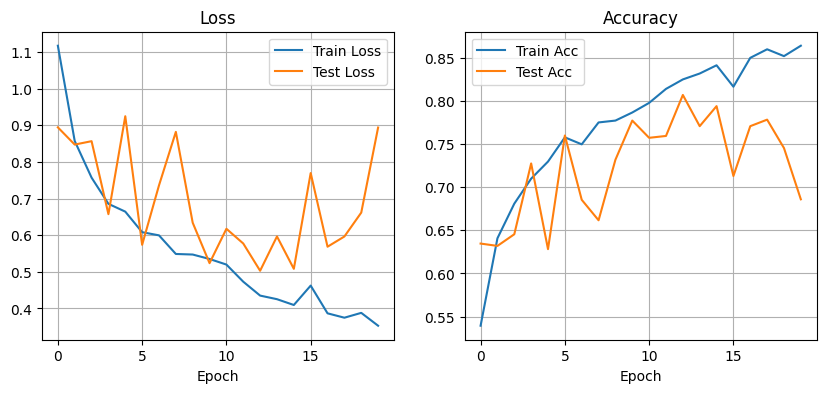

Pred: [1 0 0 4 0]
True: tensor([1, 0, 0, 3, 0])
Confusion Matrix:
 [[259  94   0   5  35]
 [  1 233   8  10   9]
 [  6  91 200  60  33]
 [ 29  59  32 279  33]
 [ 10  16  44   7 300]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.66      0.74       393
           1       0.47      0.89      0.62       261
           2       0.70      0.51      0.59       390
           3       0.77      0.65      0.70       432
           4       0.73      0.80      0.76       377

    accuracy                           0.69      1853
   macro avg       0.71      0.70      0.68      1853
weighted avg       0.72      0.69      0.69      1853


Accuracy: 0.6859





--- WINDOW_SIZE=100, STRIDE=50 ---

X shape: (5932, 100)
y shape: (5932,)
node_ids shape: (5932,)
X_data shape: (5932, 1, 100)
X_train: torch.Size([4449, 1, 100])
X_test : torch.Size([1483, 1, 100])
y_train: torch.Size([4449])
y_test : torch.Size([1483])


Epoch [1/20] Train Loss

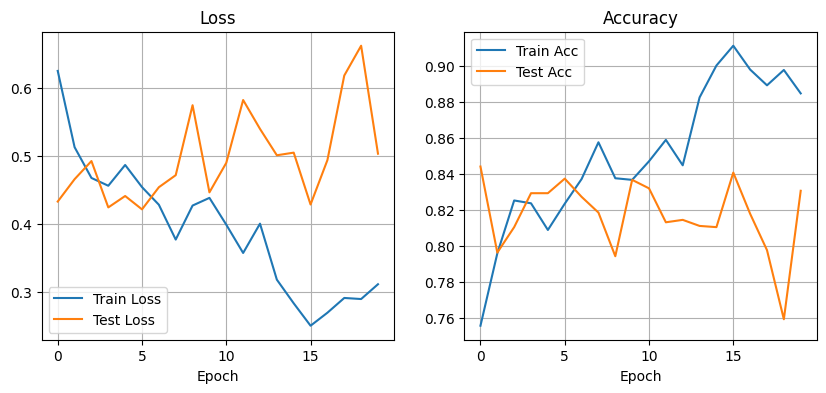

Pred: [0 2 2 1 1]
True: tensor([0, 2, 2, 2, 2])
Confusion Matrix:
 [[290  12   1   7   5]
 [  6 165  15  21   2]
 [  1   9 280  16   6]
 [ 10   8  39 268  21]
 [  8   1  61   2 229]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92       315
           1       0.85      0.79      0.82       209
           2       0.71      0.90      0.79       312
           3       0.85      0.77      0.81       346
           4       0.87      0.76      0.81       301

    accuracy                           0.83      1483
   macro avg       0.84      0.83      0.83      1483
weighted avg       0.84      0.83      0.83      1483


Accuracy: 0.8307





--- WINDOW_SIZE=500, STRIDE=40 ---

X shape: (7212, 500)
y shape: (7212,)
node_ids shape: (7212,)
X_data shape: (7212, 1, 500)
X_train: torch.Size([5409, 1, 500])
X_test : torch.Size([1803, 1, 500])
y_train: torch.Size([5409])
y_test : torch.Size([1803])


Epoch [1/20] Train Loss

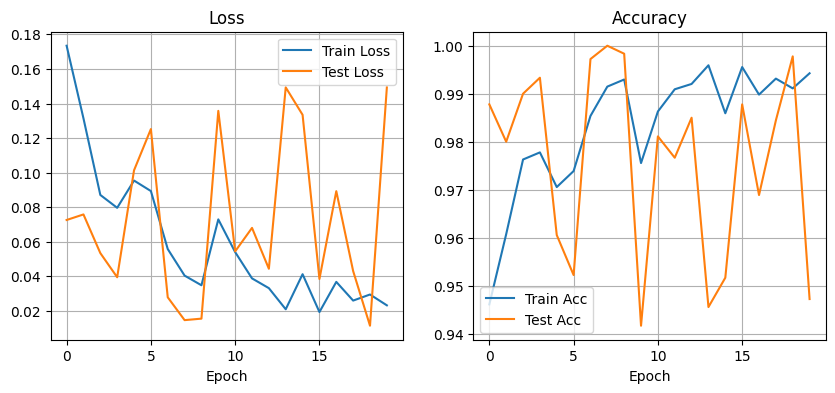

Pred: [4 0 2 0 3]
True: tensor([4, 0, 2, 0, 3])
Confusion Matrix:
 [[383   0   0   0   0]
 [  2 249   0   0   0]
 [  0   3 368   0   9]
 [  0  14   8 341  59]
 [  0   0   0   0 367]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       383
           1       0.94      0.99      0.96       251
           2       0.98      0.97      0.97       380
           3       1.00      0.81      0.89       422
           4       0.84      1.00      0.92       367

    accuracy                           0.95      1803
   macro avg       0.95      0.95      0.95      1803
weighted avg       0.95      0.95      0.95      1803


Accuracy: 0.9473





--- WINDOW_SIZE=500, STRIDE=50 ---

X shape: (5772, 500)
y shape: (5772,)
node_ids shape: (5772,)
X_data shape: (5772, 1, 500)
X_train: torch.Size([4329, 1, 500])
X_test : torch.Size([1443, 1, 500])
y_train: torch.Size([4329])
y_test : torch.Size([1443])


Epoch [1/20] Train Loss

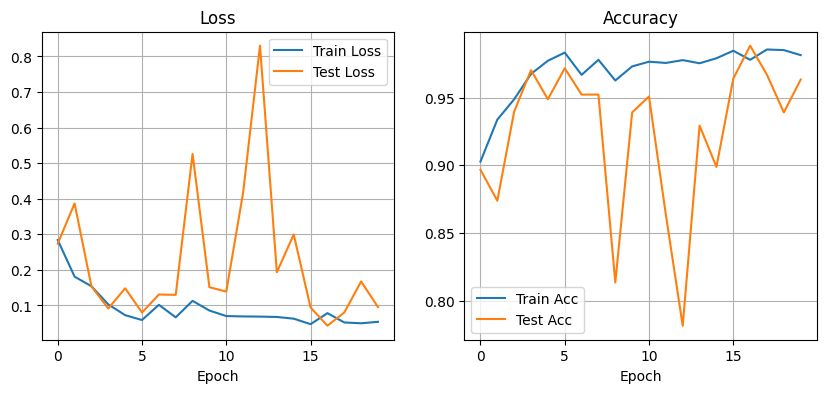

Pred: [1 0 2 2 0]
True: tensor([1, 0, 2, 2, 0])
Confusion Matrix:
 [[293   2   0  12   0]
 [  0 192   1   8   0]
 [  0   1 287   1  15]
 [  0   0   0 327  11]
 [  1   0   0   1 291]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98       307
           1       0.98      0.96      0.97       201
           2       1.00      0.94      0.97       304
           3       0.94      0.97      0.95       338
           4       0.92      0.99      0.95       293

    accuracy                           0.96      1443
   macro avg       0.97      0.96      0.96      1443
weighted avg       0.96      0.96      0.96      1443


Accuracy: 0.9633





--- WINDOW_SIZE=1000, STRIDE=40 ---

X shape: (6967, 1000)
y shape: (6967,)
node_ids shape: (6967,)
X_data shape: (6967, 1, 1000)
X_train: torch.Size([5225, 1, 1000])
X_test : torch.Size([1742, 1, 1000])
y_train: torch.Size([5225])
y_test : torch.Size([1742])


Epoch [1/20] Train

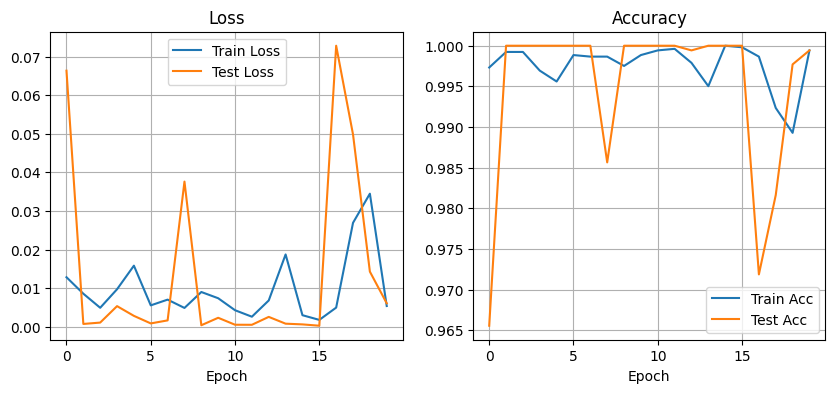

Pred: [2 0 3 2 2]
True: tensor([2, 0, 3, 2, 2])
Confusion Matrix:
 [[371   0   0   0   0]
 [  0 239   0   0   0]
 [  0   0 368   0   0]
 [  0   1   0 409   0]
 [  0   0   0   0 354]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       371
           1       1.00      1.00      1.00       239
           2       1.00      1.00      1.00       368
           3       1.00      1.00      1.00       410
           4       1.00      1.00      1.00       354

    accuracy                           1.00      1742
   macro avg       1.00      1.00      1.00      1742
weighted avg       1.00      1.00      1.00      1742


Accuracy: 0.9994





--- WINDOW_SIZE=1000, STRIDE=50 ---

X shape: (5572, 1000)
y shape: (5572,)
node_ids shape: (5572,)
X_data shape: (5572, 1, 1000)
X_train: torch.Size([4179, 1, 1000])
X_test : torch.Size([1393, 1, 1000])
y_train: torch.Size([4179])
y_test : torch.Size([1393])


Epoch [1/20] Train

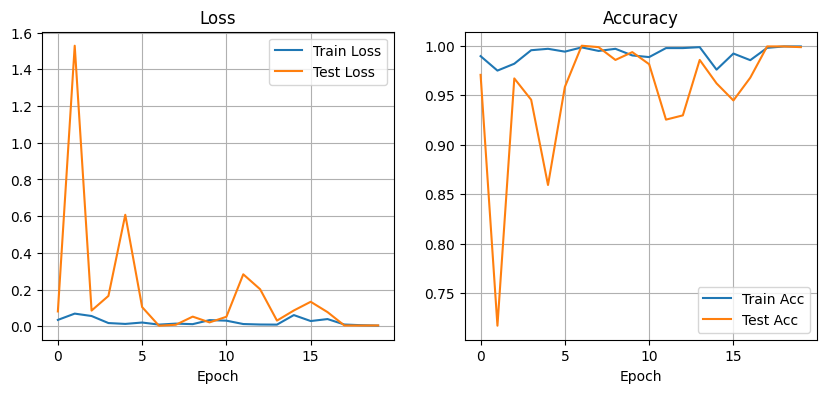

Pred: [2 0 0 1 4]
True: tensor([2, 0, 0, 1, 4])
Confusion Matrix:
 [[297   0   0   0   0]
 [  0 191   0   0   0]
 [  0   0 294   0   0]
 [  1   0   0 327   0]
 [  0   0   1   0 282]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       297
           1       1.00      1.00      1.00       191
           2       1.00      1.00      1.00       294
           3       1.00      1.00      1.00       328
           4       1.00      1.00      1.00       283

    accuracy                           1.00      1393
   macro avg       1.00      1.00      1.00      1393
weighted avg       1.00      1.00      1.00      1393


Accuracy: 0.9986






In [107]:
# ===========================
# version 1: random split
# ===========================

results_random = []

print("\n=== Version 1: random split ===\n")

for window_size in WINDOW_SIZE:
      for stride in STRIDE:
            print(f"\n--- WINDOW_SIZE={window_size}, STRIDE={stride} ---\n")
            
            X_data, y, env_ids = build_dataset(window_size, stride, node_files=node_files, env_to_label=env_to_label)

            train_loader_r, test_loader_r, X_test_r_tensor, y_test_r_tensor = random_split(X_data, y)

            train_and_evaluate(model, train_loader_r, test_loader_r, criterion, optimizer, device, num_epochs)

            predict(model, X_test_r_tensor, y_test_r_tensor, device)
            
            acc = compute_confusion_matrix(model, test_loader_r, device)
            acc = round(acc, 4)
            
            results_random.append({
            "sequence length": window_size,
            "overlapping": stride,
            "acc": acc
            })

            print("\n\n")


=== Version 2: node-based split ===


--- WINDOW_SIZE=100, STRIDE=40 ---

X shape: (7412, 100)
y shape: (7412,)
node_ids shape: (7412,)
X_data shape: (7412, 1, 100)
X_train_n_tensor shape: torch.Size([5749, 1, 100])
y_train_n_tensor shape: torch.Size([5749])

=== Version 2: Node-based Split ===
Train nodes: [0, 1, 3]
Test node : 2
X_train: torch.Size([5749, 1, 100])
X_test : torch.Size([1663, 1, 100])
y_train: torch.Size([5749])
y_test : torch.Size([1663])
Epoch [1/20] Train Loss: 0.8151, Train Acc: 0.7746 | Test Loss: 2.4400, Test Acc: 0.4985
Epoch [2/20] Train Loss: 0.3812, Train Acc: 0.8492 | Test Loss: 3.2509, Test Acc: 0.4029
Epoch [3/20] Train Loss: 0.3275, Train Acc: 0.8737 | Test Loss: 2.8689, Test Acc: 0.4366
Epoch [4/20] Train Loss: 0.2493, Train Acc: 0.9095 | Test Loss: 3.4370, Test Acc: 0.4209
Epoch [5/20] Train Loss: 0.2306, Train Acc: 0.9134 | Test Loss: 3.7709, Test Acc: 0.3656
Epoch [6/20] Train Loss: 0.2183, Train Acc: 0.9182 | Test Loss: 3.5947, Test Acc: 0.4618
Epoc

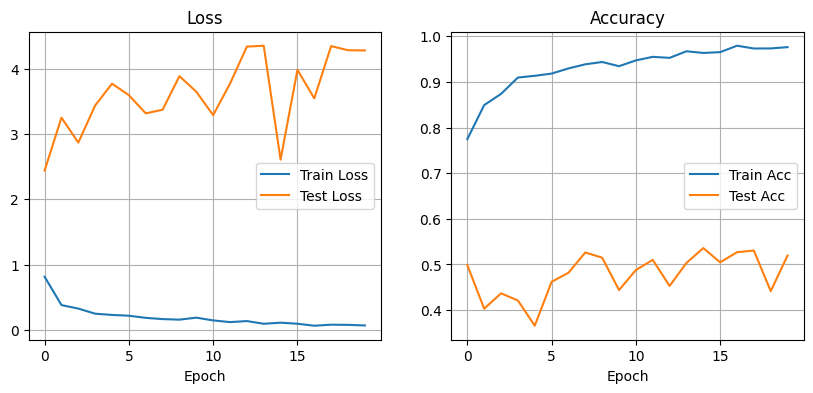

Pred: [2 3 3 3 3]
True: tensor([0, 0, 0, 0, 0])
Confusion Matrix:
 [[  0   0  18 238   0]
 [  0 110  13  53   6]
 [  0   2 377   4  63]
 [ 29  59   7  25 307]
 [  0   0   0   0 352]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       256
           1       0.64      0.60      0.62       182
           2       0.91      0.85      0.88       446
           3       0.08      0.06      0.07       427
           4       0.48      1.00      0.65       352

    accuracy                           0.52      1663
   macro avg       0.42      0.50      0.44      1663
weighted avg       0.44      0.52      0.46      1663


Accuracy: 0.5195





--- WINDOW_SIZE=100, STRIDE=50 ---

X shape: (5932, 100)
y shape: (5932,)
node_ids shape: (5932,)
X_data shape: (5932, 1, 100)
X_train_n_tensor shape: torch.Size([4601, 1, 100])
y_train_n_tensor shape: torch.Size([4601])

=== Version 2: Node-based Split ===
Train nodes: [0, 1, 3]

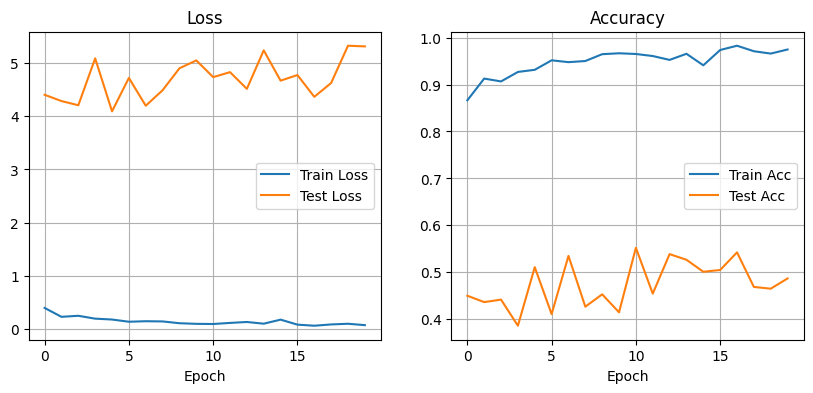

Pred: [3 3 3 3 3]
True: tensor([0, 0, 0, 0, 0])
Confusion Matrix:
 [[  0   0  13 192   0]
 [  0  79   7  51   8]
 [  0   0 287   1  69]
 [  7  77   3   0 255]
 [  0   0   0   0 282]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       205
           1       0.51      0.54      0.52       145
           2       0.93      0.80      0.86       357
           3       0.00      0.00      0.00       342
           4       0.46      1.00      0.63       282

    accuracy                           0.49      1331
   macro avg       0.38      0.47      0.40      1331
weighted avg       0.40      0.49      0.42      1331


Accuracy: 0.4869





--- WINDOW_SIZE=500, STRIDE=40 ---

X shape: (7212, 500)
y shape: (7212,)
node_ids shape: (7212,)
X_data shape: (7212, 1, 500)
X_train_n_tensor shape: torch.Size([5599, 1, 500])
y_train_n_tensor shape: torch.Size([5599])

=== Version 2: Node-based Split ===
Train nodes: [0, 1, 3]

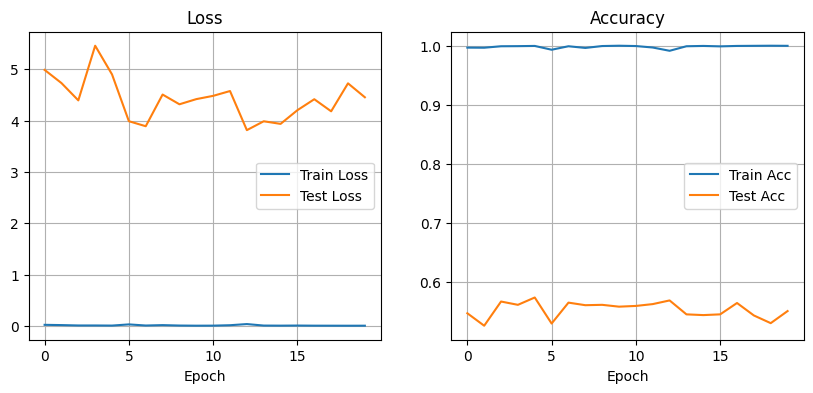

Pred: [3 3 3 3 3]
True: tensor([0, 0, 0, 0, 0])
Confusion Matrix:
 [[  0   0   0 246   0]
 [  0 136   0  36   0]
 [  0   0 410   0  26]
 [ 17 103   4   1 292]
 [  0   0   0   0 342]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       246
           1       0.57      0.79      0.66       172
           2       0.99      0.94      0.96       436
           3       0.00      0.00      0.00       417
           4       0.52      1.00      0.68       342

    accuracy                           0.55      1613
   macro avg       0.42      0.55      0.46      1613
weighted avg       0.44      0.55      0.48      1613


Accuracy: 0.5511





--- WINDOW_SIZE=500, STRIDE=50 ---

X shape: (5772, 500)
y shape: (5772,)
node_ids shape: (5772,)
X_data shape: (5772, 1, 500)
X_train_n_tensor shape: torch.Size([4481, 1, 500])
y_train_n_tensor shape: torch.Size([4481])

=== Version 2: Node-based Split ===
Train nodes: [0, 1, 3]

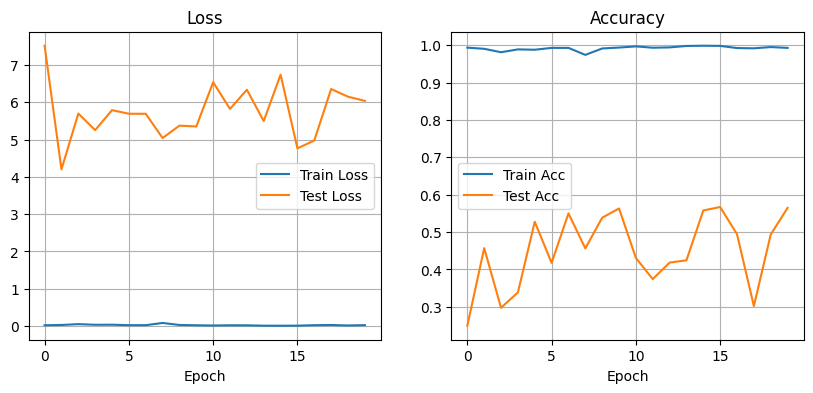

Pred: [3 3 3 3 3]
True: tensor([0, 0, 0, 0, 0])
Confusion Matrix:
 [[  0   0   0 197   0]
 [  0 137   0   0   0]
 [  0  21 318   0  10]
 [ 44  45   1   0 244]
 [  0   0   0   0 274]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       197
           1       0.67      1.00      0.81       137
           2       1.00      0.91      0.95       349
           3       0.00      0.00      0.00       334
           4       0.52      1.00      0.68       274

    accuracy                           0.56      1291
   macro avg       0.44      0.58      0.49      1291
weighted avg       0.45      0.56      0.49      1291


Accuracy: 0.5647





--- WINDOW_SIZE=1000, STRIDE=40 ---

X shape: (6967, 1000)
y shape: (6967,)
node_ids shape: (6967,)
X_data shape: (6967, 1, 1000)
X_train_n_tensor shape: torch.Size([5415, 1, 1000])
y_train_n_tensor shape: torch.Size([5415])

=== Version 2: Node-based Split ===
Train nodes: [0, 1

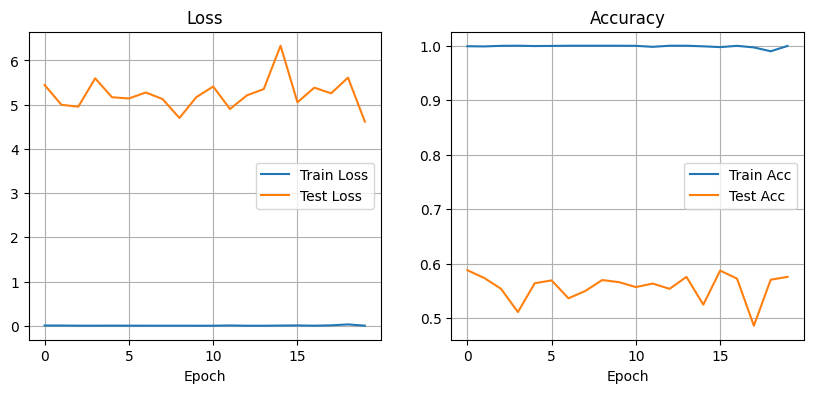

Pred: [3 3 3 3 3]
True: tensor([0, 0, 0, 0, 0])
Confusion Matrix:
 [[  0   0   0 234   0]
 [  0 143   0  16   0]
 [  0   0 421   0   3]
 [ 22 128  28   0 227]
 [  0   0   0   0 330]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       234
           1       0.53      0.90      0.67       159
           2       0.94      0.99      0.96       424
           3       0.00      0.00      0.00       405
           4       0.59      1.00      0.74       330

    accuracy                           0.58      1552
   macro avg       0.41      0.58      0.47      1552
weighted avg       0.44      0.58      0.49      1552


Accuracy: 0.5760





--- WINDOW_SIZE=1000, STRIDE=50 ---

X shape: (5572, 1000)
y shape: (5572,)
node_ids shape: (5572,)
X_data shape: (5572, 1, 1000)
X_train_n_tensor shape: torch.Size([4331, 1, 1000])
y_train_n_tensor shape: torch.Size([4331])

=== Version 2: Node-based Split ===
Train nodes: [0, 1

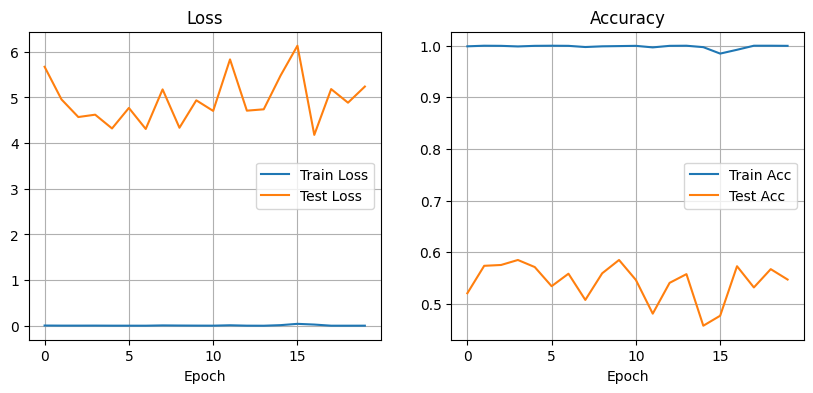

Pred: [3 3 3 3 3]
True: tensor([0, 0, 0, 0, 0])
Confusion Matrix:
 [[  0   0   0 187   0]
 [  0 103   0  24   0]
 [  0   0 312   0  27]
 [  0  71  17   0 236]
 [  0   0   0   0 264]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       187
           1       0.59      0.81      0.68       127
           2       0.95      0.92      0.93       339
           3       0.00      0.00      0.00       324
           4       0.50      1.00      0.67       264

    accuracy                           0.55      1241
   macro avg       0.41      0.55      0.46      1241
weighted avg       0.43      0.55      0.47      1241


Accuracy: 0.5471






/home/hzyc/iot-ml/ml/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hzyc/iot-ml/ml/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hzyc/iot-ml/ml/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [108]:
# ===========================
# version 2: node-based split
# ===========================

results_node = []

print("\n=== Version 2: node-based split ===\n")
for window_size in WINDOW_SIZE:
      for stride in STRIDE:
            print(f"\n--- WINDOW_SIZE={window_size}, STRIDE={stride} ---\n")
            
            X_data, y, env_ids = build_dataset(window_size, stride, node_files=node_files, env_to_label=env_to_label)

            train_loader_n, test_loader_n, X_test_n_tensor, y_test_n_tensor = node_based_split(X_data, y, env_ids)

            train_and_evaluate(model, train_loader_n, test_loader_n, criterion, optimizer, device, num_epochs)

            predict(model, X_test_n_tensor, y_test_n_tensor, device)

            acc = compute_confusion_matrix(model, test_loader_n, device)
            acc = round(acc, 4)

            results_node.append({
            "sequence length": window_size,
            "overlapping": stride,
            "acc": acc
            })
            print("\n\n")

In [109]:
df_results_ran = pd.DataFrame(results_random)
print("\n=== Random Split Accuracy Results ===\n")
print(f"{df_results_ran.to_string(index=False)}\n")

df_results_node = pd.DataFrame(results_node)
print("\n=== Node-based Split Accuracy Results ===\n")
print(f"{df_results_node.to_string(index=False)}\n")


=== Random Split Accuracy Results ===

 sequence length  overlapping    acc
             100           40 0.6859
             100           50 0.8307
             500           40 0.9473
             500           50 0.9633
            1000           40 0.9994
            1000           50 0.9986


=== Node-based Split Accuracy Results ===

 sequence length  overlapping    acc
             100           40 0.5195
             100           50 0.4869
             500           40 0.5511
             500           50 0.5647
            1000           40 0.5760
            1000           50 0.5471



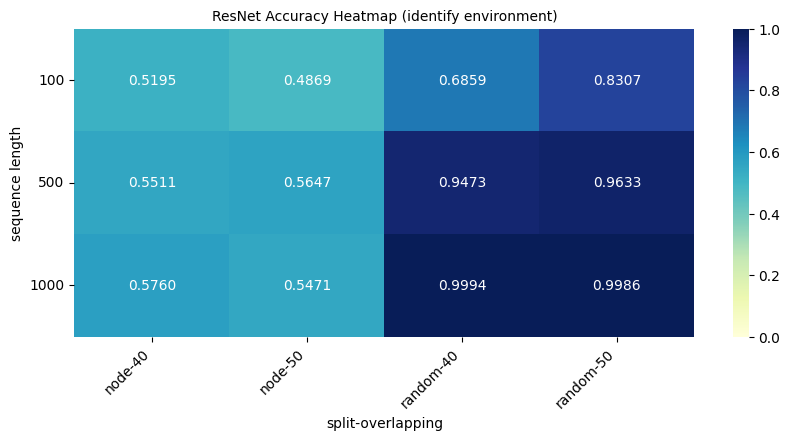

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt

df_results_ran["split"] = "random"
df_results_node["split"] = "node"

df_all = pd.concat([df_results_ran, df_results_node])

pivot_all = df_all.pivot_table(
    index="sequence length",
    columns=["split", "overlapping"],
    values="acc"
)

plt.figure(figsize=(10,4))
sns.heatmap(
    pivot_all, 
    annot=True, 
    fmt=".4f",
    cmap="YlGnBu",
    vmin=0.0, 
    vmax=1.0
)

plt.title("ResNet Accuracy Heatmap (identify environment)", fontsize=10)


plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.savefig("heatmap/heatmap_resnet_identify_env.png", bbox_inches='tight', dpi=300)